In [38]:
import pandas as pd
import numpy as np
import seaborn as ns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Downloads/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df=pd.read_csv('Downloads/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [18]:
df1=df.drop(columns=['PassengerId','Name','Cabin'])
df1.dropna(subset=['Embarked'])
df1['Age'].fillna(df1['Age'].mean())


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

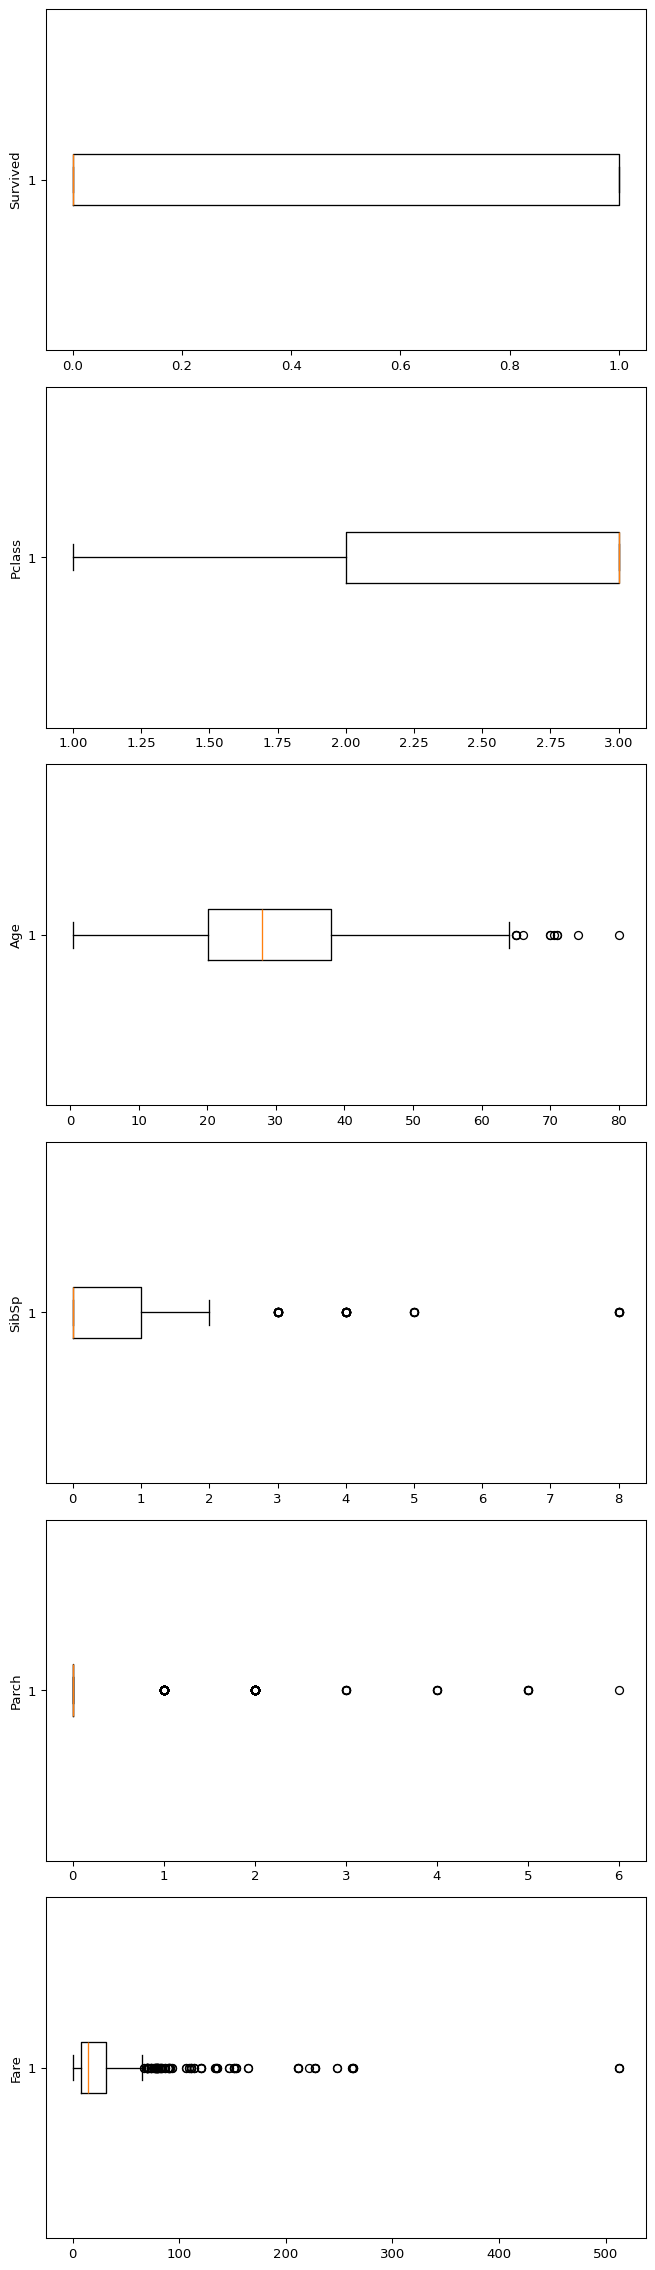

In [20]:
import matplotlib.pyplot as plt
import numpy as np

num_cols = df1.select_dtypes(include=[np.number]).columns
fig, axs = plt.subplots(len(num_cols), 1, figsize=(7, 4*len(num_cols)), dpi=95)

for i, col in enumerate(num_cols):
    axs[i].boxplot(df1[col].dropna(), vert=False)   # drop NaNs before plotting
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()


In [21]:
df1.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S


In [28]:

num_cols = df1.select_dtypes(include=[np.number]).columns
max_abs = np.max(np.abs(df1[num_cols]), axis=0)
df2= df1[num_cols]/max_abs
df2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.0,1.000000,0.2750,0.125,0.0,0.014151
1,1.0,0.333333,0.4750,0.125,0.0,0.139136
2,1.0,1.000000,0.3250,0.000,0.0,0.015469
3,1.0,0.333333,0.4375,0.125,0.0,0.103644
4,0.0,1.000000,0.4375,0.000,0.0,0.015713


In [32]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# select only numeric columns
num_cols = df1.select_dtypes(include=['number']).columns

# initialize scaler
scaler = MinMaxScaler()

# fit + transform only numeric columns
scaled_data = scaler.fit_transform(df1[num_cols])

# create a DataFrame with scaled numeric data
df3 = pd.DataFrame(scaled_data, columns=num_cols, index=df1.index)

# if you want to keep categorical columns as well, join them back
df3 = pd.concat([df3, df1.drop(columns=num_cols)], axis=1)

df3.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex,Ticket,Embarked
0,0.0,1.0,0.271174,0.125,0.0,0.014151,male,A/5 21171,S
1,1.0,0.0,0.472229,0.125,0.0,0.139136,female,PC 17599,C
2,1.0,1.0,0.321438,0.000,0.0,0.015469,female,STON/O2. 3101282,S
3,1.0,0.0,0.434531,0.125,0.0,0.103644,female,113803,S
4,0.0,1.0,0.434531,0.000,0.0,0.015713,male,373450,S


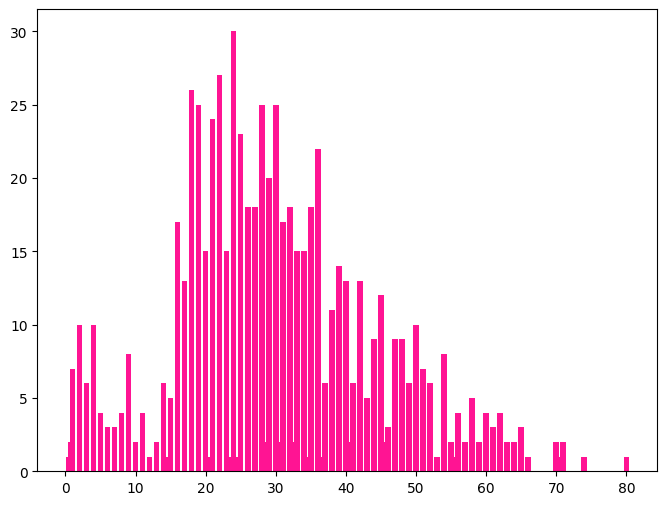

In [41]:
quality_counts = df['Age'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.show()

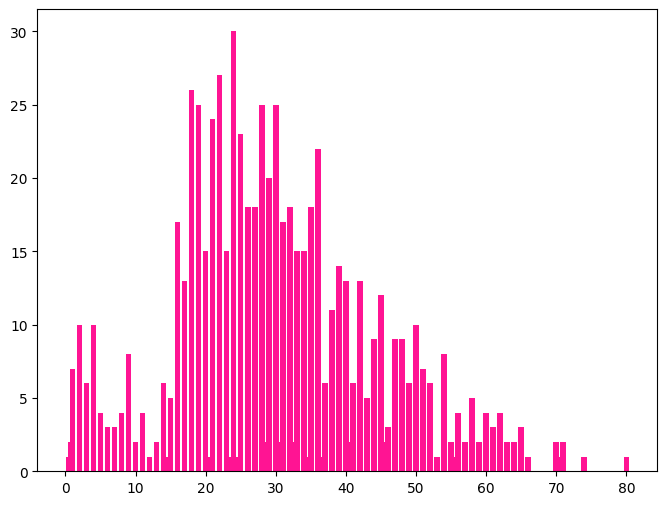

In [42]:
quality_counts = df1['Age'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.show()

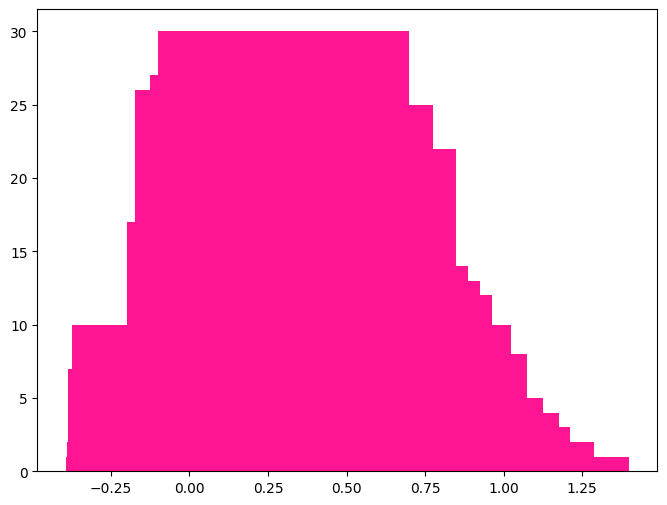

In [43]:
quality_counts = df2['Age'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.show()

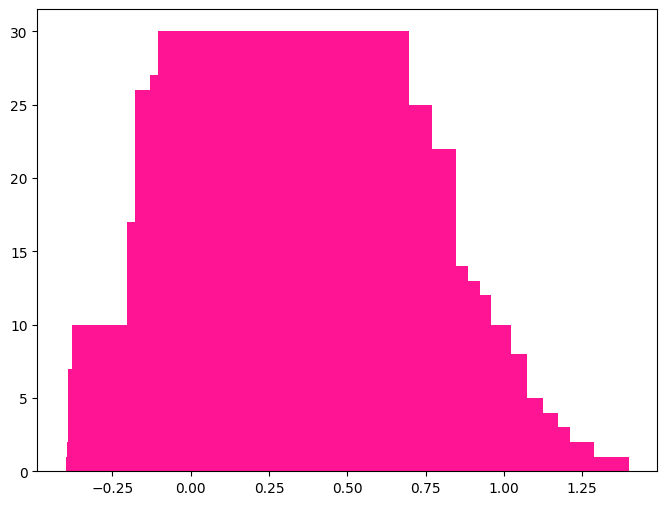

In [44]:
quality_counts = df3['Age'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.show()

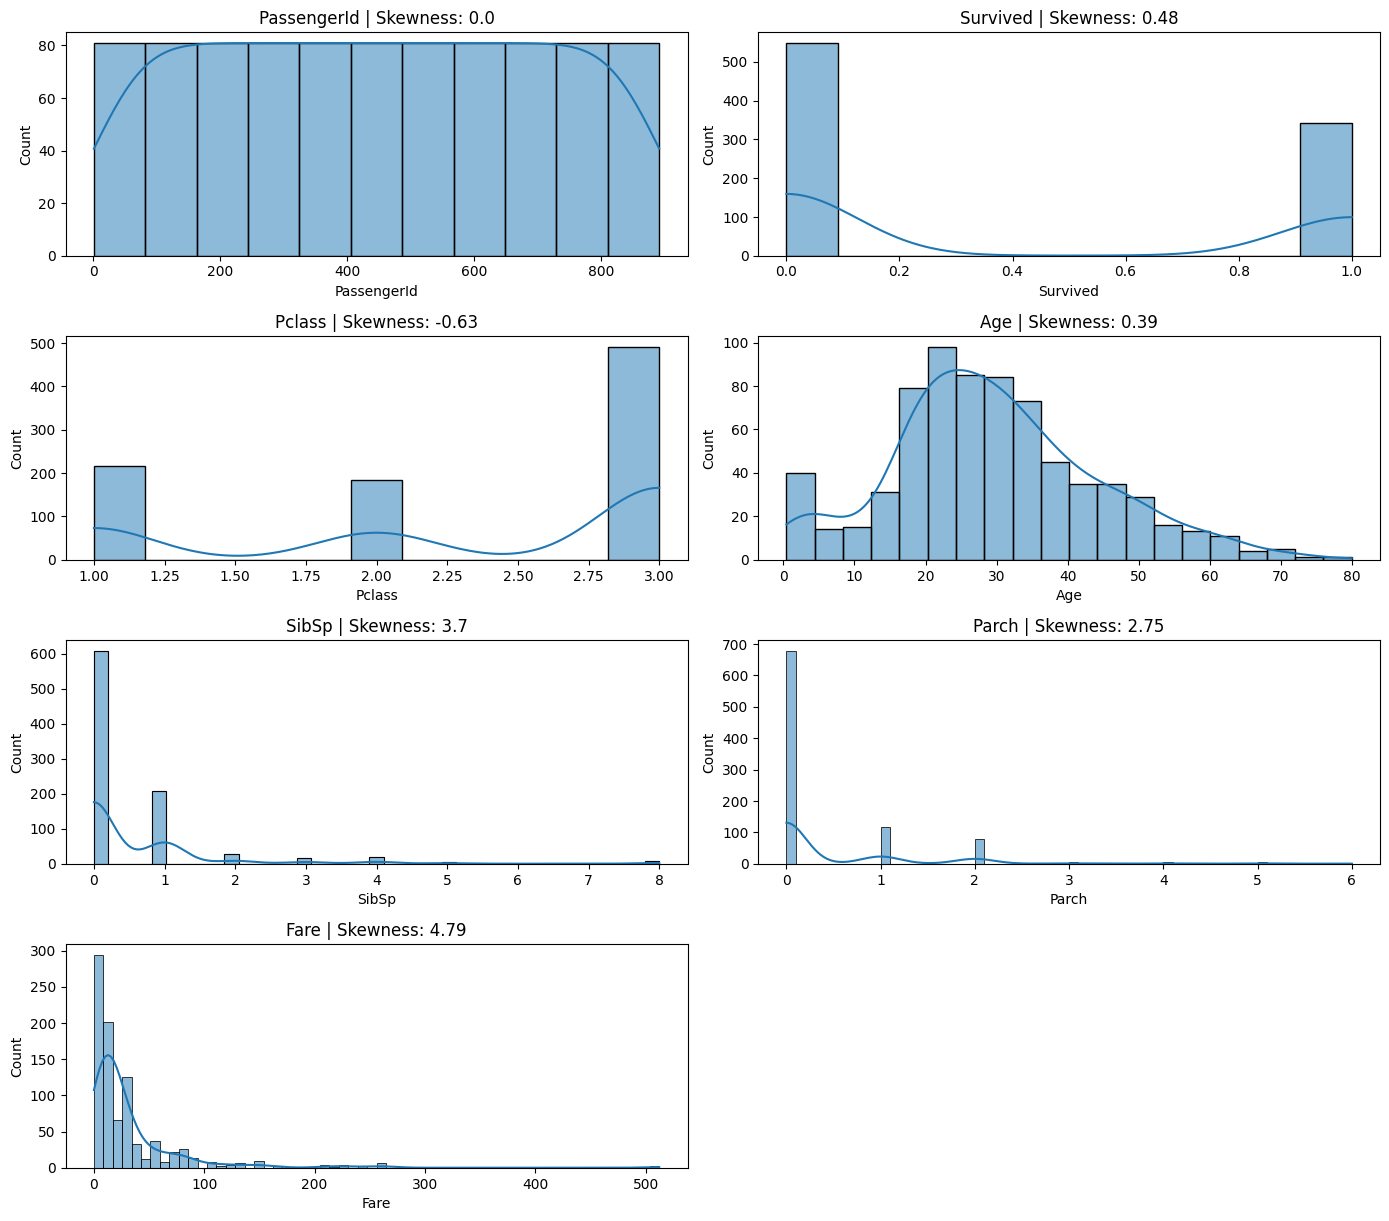

In [47]:
import seaborn as sns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.swarmplot(x="Age", y="Fare", data=df, palette='viridis')

plt.title('Swarm Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>